# Precondicionador neural para a equação de Poisson 2D

É proposto um precondicionador neural usando a arquitetura de uma U-net de modo que aprenda o mapeamento de $r \longmapsto A^{-1}r$. Ou seja, dado um resíduo, a rede deve aprender $A^{-1}r$, de modo que A é a matriz resultante da discretização por diferenças finitas do problema de Poisson 2D. O dataset, conjunto de r, é gerado de modo que o conjunto seja bastante diverso. Além disso, é feita a comparação, em termos de número de iteração e erro relativo L2, com outros precondiconadores clássicos. O solver usado de referência é o FGMRES, isso porque ele aceita sistemas não lineares.


## 1. Imports e setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import LinearOperator

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import time

SEED = 41 # número de referência para aleatóridade no conjunto r
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando em: {device}")


Rodando em: cuda


In [2]:
# setup dos gráficos

import matplotlib as mpl

mpl.rcParams.update({
    # Fontes
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset':  'cm',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   11,
    # Linhas e marcadores
    'lines.linewidth':   1.8,
    'lines.markersize':  6,
    'axes.linewidth':    1.0,
    # Grid e ticks
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  5,
    'ytick.major.size':  5,
    'xtick.minor.size':  3,
    'ytick.minor.size':  3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    # Bordas
    'axes.spines.top':   True,
    'axes.spines.right': True,
    # Salvar
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
    'figure.facecolor':  'white',
})

# Paleta de cores consistente para os 5 precondicionadores
PRECOND_COLORS = {
    "None":   "#666666",   # cinza escuro
    "Jacobi": "#E69F00",   # laranja
    "SSOR":   "#9467BD",   # roxo
    "ILU(0)": "#2E8B57",   # verde
    "Neural": "#1F77B4",   # azul
}
PRECOND_MARKERS = {
    "None":   "o",
    "Jacobi": "s",
    "SSOR":   "D",
    "ILU(0)": "^",
    "Neural": "*",
}

## 2. Matriz Laplaciana 2D

Discretização por diferenças finitas centradas. A matriz $A$ resultante é esparsa (5 diagonais), simétrica positiva definida, com tamanho $N^2 \times N^2$.


In [4]:
def build_laplacian_2d(N):
    """Constroi a matriz do operador -Delta com Dirichlet u=0."""
    h = 1.0 / (N + 1)
    diag = 4.0 * np.ones(N*N)
    off_ew = -1.0 * np.ones(N*N - 1)
    for k in range(N-1, len(off_ew), N):
        off_ew[k] = 0.0
    off_ns = -1.0 * np.ones(N*N - N)
    A = sp.diags([diag, off_ew, off_ew, off_ns, off_ns],
                 offsets=[0, 1, -1, N, -N], format='csr')
    return A, h


# Validacao com solucao analitica: u(x,y) = sin(pi*x)*sin(pi*y)
N = 32 # grid
A, h = build_laplacian_2d(N)

xs = np.linspace(h, 1-h, N)
X, Y = np.meshgrid(xs, xs, indexing='ij')
f_test = 2 * np.pi**2 * np.sin(np.pi*X) * np.sin(np.pi*Y)
u_exact = np.sin(np.pi*X) * np.sin(np.pi*Y)
b_test_v = (h**2) * f_test.ravel()
u_num = spla.spsolve(A, b_test_v).reshape(N, N)

err = np.linalg.norm(u_num - u_exact) / np.linalg.norm(u_exact)
print(f"Sistema: {A.shape}, nnz={A.nnz}")
print(f"Validacao: erro relativo = {err*100:.3f}% (esperado O(h^2) = {h**2:.4e})")


Sistema: (1024, 1024), nnz=4992
Validacao: erro relativo = 0.076% (esperado O(h^2) = 9.1827e-04)


## 3. Dataset $(\mathbf{r}, A^{-1}\mathbf{r})$ com diversidade espectral

Para a rede aprender a aplicação $A^{-1}$ de forma robusta, geramos pares de treino com **diversidade espectral**:

- **40%** ruído gaussiano (alta frequência);
- **30%** gaussianas espaciais (baixa frequência — típica de termos fonte);
- **20%** modos individuais de Fourier;
- **10%** combinações lineares de modos.

Como $A$ é fixa, fatoramos uma única vez com `spla.factorized` e aplicamos para todos os $\mathbf{r}_j$.


Gerando dataset: train=5000, val=1000, test=500
Tempo: 3.7s
r_std=1.000, z_std=1.199e+01


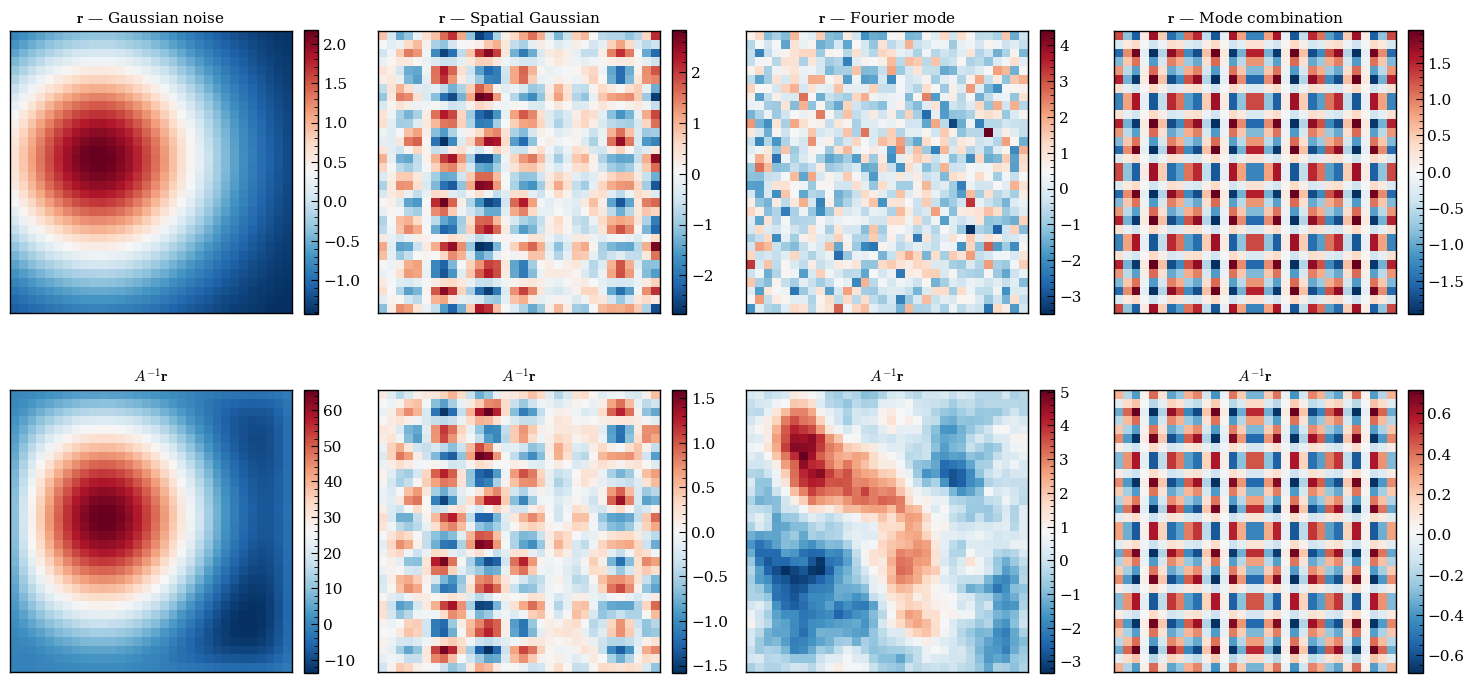

In [5]:
solve_A = spla.factorized(A.tocsc())


def generate_diverse_residuals(n_samples, N, seed=0):
    """Gera vetores com diversidade espectral."""
    rng = np.random.default_rng(seed)
    samples = []
    n_gauss   = int(0.40 * n_samples)
    n_spatial = int(0.30 * n_samples)
    n_fourier = int(0.20 * n_samples)
    n_combo   = n_samples - n_gauss - n_spatial - n_fourier

    # 1) Gaussiano branco
    for _ in range(n_gauss):
        samples.append(rng.standard_normal((N, N)))

    # 2) Gaussianas espaciais
    ii, jj = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')
    x_grid = (ii + 0.5) / N; y_grid = (jj + 0.5) / N
    for _ in range(n_spatial):
        cx, cy = rng.uniform(0.1, 0.9, 2)
        width = rng.uniform(0.02, 0.20)
        amp   = rng.uniform(-3, 3)
        sample = amp * np.exp(-((x_grid-cx)**2 + (y_grid-cy)**2) / width)
        sample = (sample - sample.mean()) / (sample.std() + 1e-12)
        samples.append(sample)

    # 3) Modos de Fourier individuais
    for _ in range(n_fourier):
        kx = rng.integers(1, N // 2 + 1)
        ky = rng.integers(1, N // 2 + 1)
        sample = np.cos(kx * np.pi * x_grid) * np.cos(ky * np.pi * y_grid)
        sample = (sample - sample.mean()) / (sample.std() + 1e-12)
        samples.append(sample)

    # 4) Combinacoes de modos
    for _ in range(n_combo):
        sample = np.zeros((N, N))
        n_modes = rng.integers(5, 15)
        for _ in range(n_modes):
            kx = rng.integers(1, N // 2 + 1)
            ky = rng.integers(1, N // 2 + 1)
            coef = rng.standard_normal()
            sample += coef * np.cos(kx * np.pi * x_grid) * np.cos(ky * np.pi * y_grid)
        sample = (sample - sample.mean()) / (sample.std() + 1e-12)
        samples.append(sample)

    arr = np.array(samples)
    rng.shuffle(arr)
    return arr


# Geracao do dataset
N_TRAIN = 5000
N_VAL   = 1000
N_TEST  = 500

print(f"Gerando dataset: train={N_TRAIN}, val={N_VAL}, test={N_TEST}")
t0 = time.time()
R_train = generate_diverse_residuals(N_TRAIN, N, seed=SEED)
Z_train = np.array([solve_A(r.ravel()).reshape(N, N) for r in R_train])
R_val   = generate_diverse_residuals(N_VAL,   N, seed=SEED+1)
Z_val   = np.array([solve_A(r.ravel()).reshape(N, N) for r in R_val])
R_test  = generate_diverse_residuals(N_TEST,  N, seed=SEED+2)
Z_test  = np.array([solve_A(r.ravel()).reshape(N, N) for r in R_test])
print(f"Tempo: {time.time()-t0:.1f}s")

# Normalizacao
r_std = R_train.std()
z_std = Z_train.std()
print(f"r_std={r_std:.3f}, z_std={z_std:.3e}")

# Tensores na GPU
Xtr = torch.from_numpy(R_train / r_std).float().unsqueeze(1).to(device)
Ytr = torch.from_numpy(Z_train / z_std).float().unsqueeze(1).to(device)
Xvl = torch.from_numpy(R_val   / r_std).float().unsqueeze(1).to(device)
Yvl = torch.from_numpy(Z_val   / z_std).float().unsqueeze(1).to(device)
Xte = torch.from_numpy(R_test  / r_std).float().unsqueeze(1).to(device)

# Visualiza 4 tipos de input
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
type_labels = ["Gaussian noise", "Spatial Gaussian", "Fourier mode", "Mode combination"]
for i, ax in enumerate(axes[0]):
    im = ax.imshow(R_train[i], cmap="RdBu_r")
    ax.set_title(f"$\\mathbf{{r}}$ — {type_labels[i]}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i, ax in enumerate(axes[1]):
    im = ax.imshow(Z_train[i], cmap="RdBu_r")
    ax.set_title(f"$A^{{-1}}\\mathbf{{r}}$", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fig_dataset.pdf")
plt.show()


## 4. Arquitetura U-Net

Rede com 3 níveis de profundidade ($32 \to 16 \to 8$). Input de 1 canal (resíduo $\mathbf{r}$), output de 1 canal ($A^{-1}\mathbf{r}$). Upsampling bilinear (sem checkerboard artifacts).


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, c=32):
        super().__init__()
        self.enc1 = DoubleConv(1, c)
        self.enc2 = DoubleConv(c, 2*c)
        self.enc3 = DoubleConv(2*c, 4*c)
        self.bot  = DoubleConv(4*c, 8*c)
        self.up3  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(8*c, 4*c, 3, padding=1, bias=False),
        )
        self.dec3 = DoubleConv(8*c, 4*c)
        self.up2  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(4*c, 2*c, 3, padding=1, bias=False),
        )
        self.dec2 = DoubleConv(4*c, 2*c)
        self.up1  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(2*c, c, 3, padding=1, bias=False),
        )
        self.dec1 = DoubleConv(2*c, c)
        self.out_conv = nn.Conv2d(c, 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out_conv(d1)


model = UNet(c=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parametros: {n_params:,}")


Parametros: 2,141,249


## 5. Treino

AdamW + cosine annealing. Loss: SmoothL1 (Huber).


Treinando (1000 epocas)...
  ep   1: tr=4.1692e-02  vl=3.6236e-02
  ep  10: tr=1.4604e-02  vl=2.8978e-03
  ep  20: tr=1.1282e-02  vl=2.7566e-02
  ep  30: tr=4.5641e-03  vl=1.0823e-02
  ep  40: tr=3.2072e-03  vl=1.0094e-03
  ep  50: tr=2.9705e-03  vl=8.7115e-03
  ep  60: tr=2.7468e-03  vl=3.7818e-03
  ep  70: tr=2.4772e-03  vl=4.9604e-03
  ep  80: tr=2.0115e-03  vl=3.3524e-03
  ep  90: tr=2.7072e-03  vl=2.7286e-03
  ep 100: tr=2.0534e-03  vl=1.8380e-03
  ep 110: tr=1.2061e-03  vl=2.2847e-03
  ep 120: tr=8.0401e-04  vl=7.6509e-04
  ep 130: tr=9.3013e-04  vl=4.0672e-03
  ep 140: tr=1.7956e-03  vl=1.9637e-03
  ep 150: tr=8.5143e-04  vl=2.3111e-03
  ep 160: tr=1.5714e-03  vl=3.0372e-03
  ep 170: tr=8.1636e-04  vl=4.6937e-03
  ep 180: tr=7.2552e-04  vl=1.5119e-03
  ep 190: tr=8.7173e-04  vl=1.6383e-03
  ep 200: tr=8.7439e-04  vl=2.5293e-04
  ep 210: tr=6.1167e-04  vl=3.5623e-03
  ep 220: tr=6.1183e-04  vl=2.2909e-03
  ep 230: tr=8.6521e-04  vl=1.3186e-03
  ep 240: tr=7.5023e-04  vl=2.2341e-0

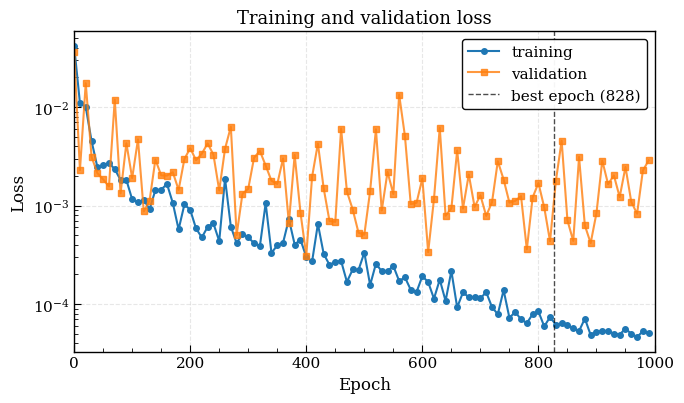

In [7]:
train_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xvl, Yvl), batch_size=64, shuffle=False)

EPOCHS = 1000
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.SmoothL1Loss()

train_losses, val_losses = [], []
best_val = float('inf'); best_state = None; best_ep = 0

print(f"Treinando ({EPOCHS} epocas)...")
t_start = time.time()
for ep in range(EPOCHS):
    model.train()
    run = 0.0
    for xb, yb in train_loader:
        loss = criterion(model(xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        run += loss.item() * xb.size(0)
    train_losses.append(run / len(train_loader.dataset))

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            vl += criterion(model(xb), yb).item() * xb.size(0)
    val_losses.append(vl / len(val_loader.dataset))

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_ep = ep + 1

    scheduler.step()
    if (ep+1) % 10 == 0 or ep == 0:
        print(f"  ep {ep+1:3d}: tr={train_losses[-1]:.4e}  vl={val_losses[-1]:.4e}")

print(f"\nTempo: {time.time()-t_start:.1f}s")
print(f"Melhor epoca: {best_ep} (val loss = {best_val:.4e})")
model.load_state_dict(best_state)

# Curva
fig, ax = plt.subplots(figsize=(7, 4.2))

step = 10 #plotar pontos a cada step na curva de loss
idx = np.arange(0, len(train_losses), step)

ax.semilogy(idx, np.array(train_losses)[idx], label="training",   color="#1F77B4", linewidth=1.5, marker='o', markersize=4)
ax.semilogy(idx, np.array(val_losses)[idx],   label="validation", color="#FF7F0E", linewidth=1.5, marker='s', markersize=4, alpha=0.8)
ax.axvline(best_ep-1, color="black", linestyle="--", linewidth=1, alpha=0.7,
           label=f"best epoch ({best_ep})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and validation loss")
ax.legend(loc='upper right', framealpha=0.95, edgecolor='black')
ax.set_xlim([0, len(train_losses)])
plt.tight_layout()
save_fig("loss_curve")
plt.show()

## 6. Sanity check

Verifica quão bem a rede aproxima $A^{-1}\mathbf{r}$ no conjunto de teste — sem nenhum método iterativo, apenas aplicação direta.


Aproximacao de A^-1 r no conjunto de teste:
  L2 mediano: 4.68%
  L2 medio:   5.34%


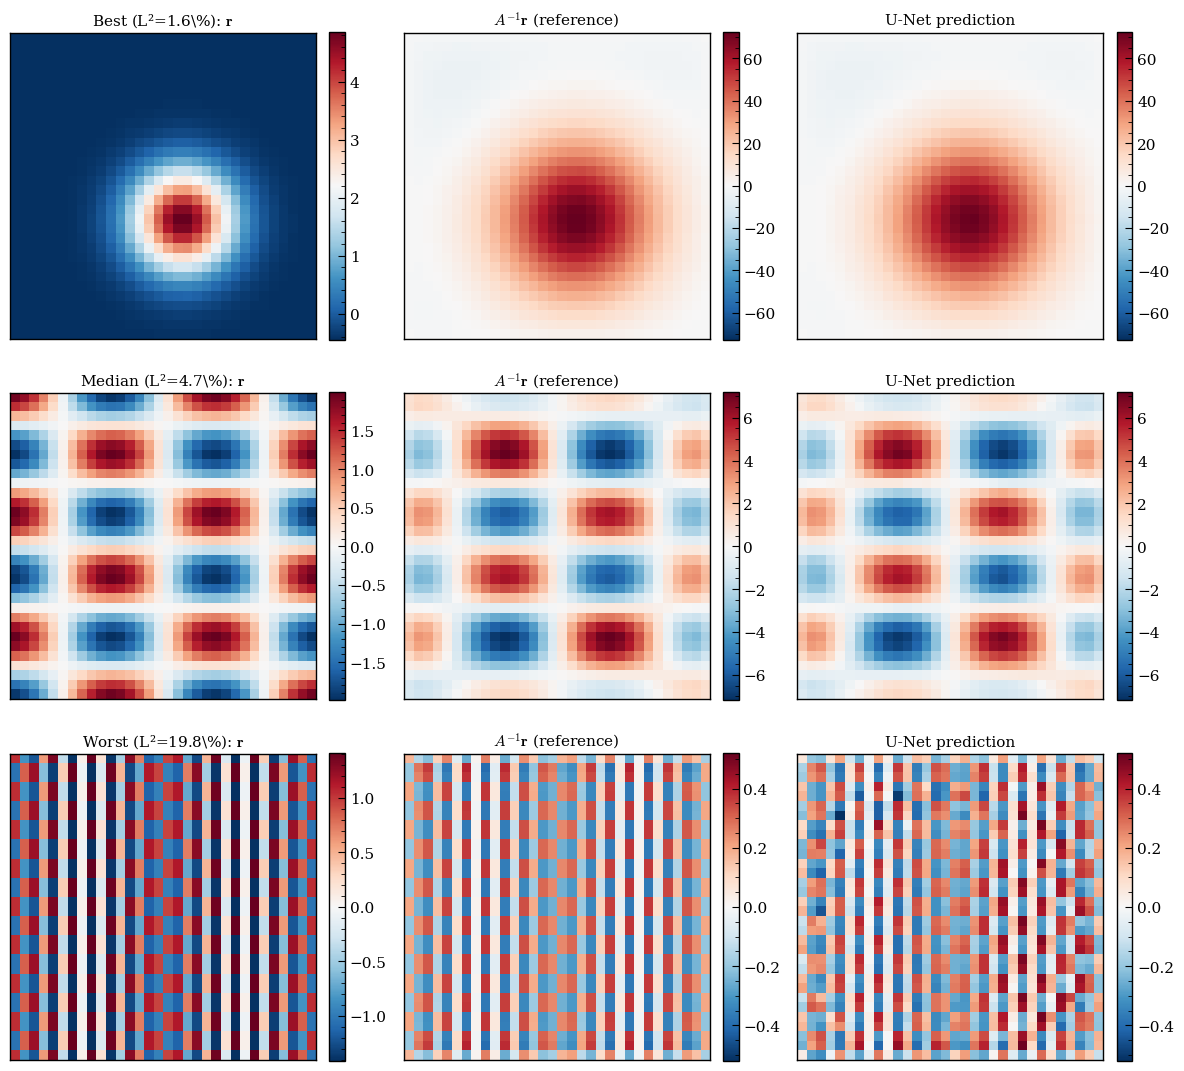

In [8]:
def rel_L2(pred, truth):
    num = np.sqrt(np.sum((pred-truth)**2, axis=(1,2)))
    den = np.sqrt(np.sum(truth**2, axis=(1,2)))
    return num / den


model.eval()
with torch.no_grad():
    pred_n = model(Xte).cpu().numpy().squeeze(1)
pred_test = pred_n * z_std

err_test = rel_L2(pred_test, Z_test)
print(f"Aproximacao de A^-1 r no conjunto de teste:")
print(f"  L2 mediano: {np.median(err_test)*100:.2f}%")
print(f"  L2 medio:   {err_test.mean()*100:.2f}%")

idx_best   = int(np.argmin(err_test))
idx_median = int(np.argsort(err_test)[len(err_test)//2])
idx_worst  = int(np.argmax(err_test))

fig, axes = plt.subplots(3, 3, figsize=(12, 11))
row_labels = [
    ("Best",   idx_best),
    ("Median", idx_median),
    ("Worst",  idx_worst),
]

for row, (lbl, i) in enumerate(row_labels):
    vmax = max(np.abs(Z_test[i]).max(), np.abs(pred_test[i]).max())

    im = axes[row, 0].imshow(R_test[i], cmap="RdBu_r")
    axes[row, 0].set_title(f"{lbl} (L²={err_test[i]*100:.1f}\\%): $\\mathbf{{r}}$", fontsize=11)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    plt.colorbar(im, ax=axes[row, 0], fraction=0.046, pad=0.04)

    im = axes[row, 1].imshow(Z_test[i], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[row, 1].set_title("$A^{-1}\\mathbf{r}$ (reference)", fontsize=11)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

    im = axes[row, 2].imshow(pred_test[i], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[row, 2].set_title("U-Net prediction", fontsize=11)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("fig_sanity_check.pdf")
plt.show()


## 7. Aplicação da rede com correção de escala

A rede foi treinada em inputs com norma típica $\sqrt{N^2}$ (gaussianos). Em uso prático, o input pode ter qualquer norma. Como $A^{-1}$ é **linear**, aplicamos a propriedade:
$$A^{-1}(\alpha \mathbf{r}) = \alpha A^{-1}\mathbf{r}$$
para reescalar o input para a norma típica do treino, aplicar a rede, e desfazer a escala. Isso é matematicamente exato e estabiliza a aplicação numérica para vetores com normas muito diferentes do treino.


In [9]:

model_cpu = model.cpu().eval()


def neural_inverse_apply(b_vec):
    """Aplica a rede neural como aproximacao de A^{-1}, com correcao de escala."""
    target_norm = np.sqrt(N * N)
    b_norm = np.linalg.norm(b_vec)
    if b_norm < 1e-30:
        return np.zeros_like(b_vec)
    scale = target_norm / b_norm
    b_scaled = b_vec * scale
    b_input = b_scaled.reshape(N, N) / r_std
    with torch.no_grad():
        inp = torch.from_numpy(b_input).float().unsqueeze(0).unsqueeze(0)
        out = model_cpu(inp).numpy().squeeze()
    u_scaled = (out * z_std).ravel()
    return u_scaled / scale


## 8. Implementação do Flexible GMRES (FGMRES)

O FGMRES é uma variante do GMRES desenhada para precondicionadores não-lineares ou que mudam a cada iteração. A diferença chave é que ele armazena os vetores **precondicionados** $z_j = M(v_j)$ separadamente dos vetores de Krylov, e constrói a solução final usando $z_j$ ao invés de $v_j$. Isso elimina a hipótese de linearidade do GMRES padrão.

In [10]:
def fgmres(A, b, M, tol=1e-6, max_iter=200, restart=30):
    """Flexible GMRES — tolera precondicionadores nao-lineares.

    Diferenca do GMRES padrao: armazena os vetores precondicionados z_j = M(v_j)
    separadamente, em vez de assumir M linear.

    Retorna (x, residuals, converged, iterations).
    """
    n = len(b)
    x = np.zeros(n)
    b_norm = np.linalg.norm(b)
    if b_norm == 0:
        return x, [0.0], True, 0

    residuals = []
    total_iters = 0

    for outer in range(max_iter // restart + 1):
        r = b - A @ x
        beta = np.linalg.norm(r)
        rel_res = beta / b_norm
        residuals.append(rel_res)

        if rel_res < tol:
            return x, residuals, True, total_iters

        # Bases V (Krylov) e Z (precondicionada)
        V = np.zeros((n, restart + 1))
        Z = np.zeros((n, restart))
        H = np.zeros((restart + 1, restart))
        V[:, 0] = r / beta

        # vetor reduzido para problema de minimos quadrados
        g = np.zeros(restart + 1)
        g[0] = beta

        # rotacoes de Givens
        cs = np.zeros(restart)
        sn = np.zeros(restart)

        j_final = restart
        for j in range(restart):
            # Aplica precondicionador (pode ser nao-linear)
            Z[:, j] = M(V[:, j]) if callable(M) else M @ V[:, j]
            # Aplica A
            w = A @ Z[:, j]

            # Arnoldi: ortogonaliza w contra V[:, :j+1]
            for i in range(j + 1):
                H[i, j] = np.dot(V[:, i], w)
                w = w - H[i, j] * V[:, i]

            H[j + 1, j] = np.linalg.norm(w)
            if H[j + 1, j] > 1e-14:
                V[:, j + 1] = w / H[j + 1, j]

            # Aplica rotacoes de Givens anteriores na coluna j
            for i in range(j):
                temp = cs[i] * H[i, j] + sn[i] * H[i + 1, j]
                H[i + 1, j] = -sn[i] * H[i, j] + cs[i] * H[i + 1, j]
                H[i, j] = temp

            # Nova rotacao de Givens
            denom = np.sqrt(H[j, j]**2 + H[j + 1, j]**2)
            cs[j] = H[j, j] / denom
            sn[j] = H[j + 1, j] / denom
            H[j, j] = denom
            H[j + 1, j] = 0

            # Atualiza g
            g[j + 1] = -sn[j] * g[j]
            g[j] = cs[j] * g[j]

            rel_res = abs(g[j + 1]) / b_norm
            residuals.append(rel_res)
            total_iters += 1

            if rel_res < tol:
                j_final = j + 1
                break

        # Resolve sistema triangular H[:j_final, :j_final] y = g[:j_final]
        y = np.zeros(j_final)
        for i in range(j_final - 1, -1, -1):
            y[i] = (g[i] - np.dot(H[i, i+1:j_final], y[i+1:j_final])) / H[i, i]

        # Atualiza solucao x usando Z (e nao V) — chave do FGMRES
        x = x + Z[:, :j_final] @ y

        if rel_res < tol:
            return x, residuals, True, total_iters

    return x, residuals, False, total_iters


# Teste em UM problema canonico (gaussiana centrada)
xs = np.linspace(h, 1-h, N)
X_g, Y_g = np.meshgrid(xs, xs, indexing='ij')
f = np.exp(-((X_g - 0.5)**2 + (Y_g - 0.5)**2) / 0.05)
b_test = (h**2) * f.ravel()

print("Teste rapido: FGMRES + rede neural em UM problema:\n")
t0 = time.time()
x, res_history, converged, n_iters = fgmres(A, b_test, neural_inverse_apply, tol=1e-6, max_iter=300, restart=30)
t = time.time() - t0
final_res = np.linalg.norm(b_test - A @ x) / np.linalg.norm(b_test)

u_exact = solve_A(b_test)
err_vs_exact = np.linalg.norm(x - u_exact) / np.linalg.norm(u_exact)

print(f"  Iteracoes: {n_iters}")
print(f"  Convergiu: {converged}")
print(f"  Tempo:     {t*1000:.1f}ms")
print(f"  Residuo:   {final_res:.2e}")
print(f"  Erro vs spsolve: {err_vs_exact*100:.4f}%")


Teste rapido: FGMRES + rede neural em UM problema:

  Iteracoes: 12
  Convergiu: True
  Tempo:     273.2ms
  Residuo:   3.72e-07
  Erro vs spsolve: 0.0000%


## 9. Benchmark: FGMRES com 4 precondicionadores em vários problemas

Comparamos FGMRES com 4 precondicionadores em problemas distintos (gaussianas em posições e larguras aleatórias):
1. **None** — sem precondicionador.
2. **Jacobi** — $M = \text{diag}(A)^{-1}$.
3. **ILU(0)** — fatoração incompleta.
4. **Neural** — U-Net treinada.

Usamos FGMRES em todos para comparação justa (mesmo solver, diferentes precondicionadores).


In [11]:
# Recria precondicionadores como funcoes M(r) (compativeis com FGMRES)
def make_identity():
    return lambda r: r.copy()

def make_jacobi(A):
    diag_inv = 1.0 / A.diagonal()
    return lambda r: r * diag_inv

def make_ilu(A):
    ilu = spla.spilu(A.tocsc())
    return lambda r: ilu.solve(r)

def make_ssor(A, omega=1.85):
    """SSOR (Symmetric Successive Over-Relaxation) como precondicionador.

    Decomposicao A = D + L + L^T (Laplaciana e simetrica, entao U = L^T).
    M_SSOR = (1/(omega*(2-omega))) * (D + omega*L) * D^{-1} * (D + omega*L^T)

    Aplicar M^{-1}*r = forward sweep + diagonal scale + backward sweep.
    """
    D_diag = A.diagonal()
    L = sp.tril(A, k=-1).tocsr()
    Lt = L.T.tocsr()

    def apply(r):
        # Forward sweep: resolve (D/omega + L) y = r
        # Equivale a (D + omega*L) y = omega*r, ou y = (D + omega*L)^{-1} (omega*r)
        # Triangular inferior, simples de resolver
        n = len(r)
        y = np.zeros(n)
        L_csr = L
        for i in range(n):
            # y[i] = (omega*r[i] - sum(L[i,j]*y[j] for j<i)) / D[i]
            row_start = L_csr.indptr[i]
            row_end = L_csr.indptr[i+1]
            cols = L_csr.indices[row_start:row_end]
            vals = L_csr.data[row_start:row_end]
            mask = cols < i
            sub = np.dot(vals[mask], y[cols[mask]])
            y[i] = (omega * r[i] - omega * sub) / D_diag[i]

        # Diagonal scale + backward sweep: resolve (D/omega + L^T) z = (D/omega) y
        # Equivale a z = (D + omega*L^T)^{-1} D y
        z = np.zeros(n)
        Lt_csr = Lt
        for i in range(n - 1, -1, -1):
            row_start = Lt_csr.indptr[i]
            row_end = Lt_csr.indptr[i+1]
            cols = Lt_csr.indices[row_start:row_end]
            vals = Lt_csr.data[row_start:row_end]
            mask = cols > i
            sub = np.dot(vals[mask], z[cols[mask]])
            z[i] = (D_diag[i] * y[i] - omega * sub) / D_diag[i]

        # Fator de escala da formula completa
        z = z * (2 - omega) / omega
        return z
    return apply


precond_factories = {
    "None":   make_identity,
    "Jacobi": lambda: make_jacobi(A),
    "SSOR":   lambda: make_ssor(A, omega=1.85),   # <-- NOVA LINHA
    "ILU(0)": lambda: make_ilu(A),
    "Neural": lambda: neural_inverse_apply,
}


def generate_random_f(rng, X_g, Y_g):
    """Gera um termo fonte f de uma das 5 categorias com probabilidades iguais.

    Categorias:
      0 - Gaussiana unica (caso original)
      1 - Mistura de 2-3 gaussianas (multiplas fontes)
      2 - Constante (f = 1 em todo o dominio)
      3 - Modo de Fourier (padrao oscilatorio suave)
      4 - Gradiente linear (campo externo linear)
    """
    tipo = rng.integers(5)

    if tipo == 0:
        cx, cy = rng.uniform(0.2, 0.8, 2)
        w = rng.uniform(0.02, 0.10)
        return np.exp(-((X_g - cx)**2 + (Y_g - cy)**2) / w), "gaussiana"

    elif tipo == 1:
        n_blobs = rng.integers(2, 4)
        f = np.zeros_like(X_g)
        for _ in range(n_blobs):
            cx, cy = rng.uniform(0.15, 0.85, 2)
            w = rng.uniform(0.02, 0.08)
            amp = rng.uniform(0.5, 1.5)
            f += amp * np.exp(-((X_g - cx)**2 + (Y_g - cy)**2) / w)
        return f, "multi-gauss"

    elif tipo == 2:
        return np.ones_like(X_g), "constante"

    elif tipo == 3:
        kx = rng.integers(1, 4)
        ky = rng.integers(1, 4)
        return np.sin(kx * np.pi * X_g) * np.sin(ky * np.pi * Y_g), "Fourier"

    else:  # tipo == 4
        ax = rng.uniform(-1, 1)
        ay = rng.uniform(-1, 1)
        return ax * X_g + ay * Y_g + 1.0, "gradiente"


# Benchmark em N_BENCH problemas
N_BENCH = 200 # número de problemas

bench_rng = np.random.default_rng(123)
results = {n: {"iters": [], "time": [], "conv": [], "err": []} for n in precond_factories}

# Conta de quantos problemas de cada tipo
contador_tipos = {}

print(f"Benchmark FGMRES com {N_BENCH} problemas (5 categorias de f)...\n")
t0 = time.time()
for k in range(N_BENCH):
    f, tipo_f = generate_random_f(bench_rng, X_g, Y_g)
    contador_tipos[tipo_f] = contador_tipos.get(tipo_f, 0) + 1
    b = (h**2) * f.ravel()
    u_exact_k = solve_A(b)

    line = f"  prob {k+1:3d} [{tipo_f:11s}]: "
    for name, factory in precond_factories.items():
        M = factory()
        ti = time.time()
        x, _, conv, n_it = fgmres(A, b, M, tol=1e-6, max_iter=300, restart=30)
        ti = time.time() - ti
        err = np.linalg.norm(x - u_exact_k) / np.linalg.norm(u_exact_k)
        results[name]["iters"].append(n_it)
        results[name]["time"].append(ti)
        results[name]["conv"].append(conv)
        results[name]["err"].append(err)
        line += f"{name}={n_it}({'OK' if conv else 'X'}) "
    # Imprime so a cada 10 problemas pra nao poluir
    if (k+1) % 10 == 0 or k == 0:
        print(line)

print(f"\nTempo total: {time.time()-t0:.1f}s\n")
print(f"Distribuicao dos tipos de f gerados:")
for tipo, n in sorted(contador_tipos.items()):
    print(f"  {tipo}: {n} problemas")

# Tabela
import pandas as pd
rows = []
for name, data in results.items():
    its = np.array(data["iters"])
    tms = np.array(data["time"]) * 1000
    convs = np.array(data["conv"])
    errs = np.array(data["err"])
    rows.append({
        "Precondicionador": name,
        "Conv (%)":         f"{convs.mean()*100:.0f}",
        "Iters mediana":    int(np.median(its)),
        "Iters media":      f"{its.mean():.1f}",
        "Tempo med (ms)":   f"{np.median(tms):.1f}",
        "Erro vs exato":    f"{np.median(errs)*100:.2e}",
    })
print("\n" + pd.DataFrame(rows).to_string(index=False))

Benchmark FGMRES com 200 problemas (5 categorias de f)...

  prob   1 [gaussiana  ]: None=171(OK) Jacobi=171(OK) SSOR=21(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  10 [constante  ]: None=91(OK) Jacobi=91(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  20 [gradiente  ]: None=176(OK) Jacobi=176(OK) SSOR=21(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  30 [constante  ]: None=91(OK) Jacobi=91(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  40 [constante  ]: None=91(OK) Jacobi=91(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  50 [Fourier    ]: None=1(OK) Jacobi=1(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=11(OK) 
  prob  60 [gradiente  ]: None=141(OK) Jacobi=141(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  70 [gradiente  ]: None=156(OK) Jacobi=156(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  80 [gaussiana  ]: None=135(OK) Jacobi=135(OK) SSOR=20(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob  90 [multi-gauss]: None=140(OK) Jacobi=140(OK) SSOR=21(OK) ILU(0)=3(OK) Neural=12(OK) 
  prob 100 

## 10. Visualização: convergência dos 4 precondicionadores

Curva de $\|\mathbf{r}_k\|/\|\mathbf{b}\|$ vs. iteração para um problema representativo, com os 4 precondicionadores no FGMRES. Permite ver visualmente a aceleração relativa.


  -> salvo: /content/figures/fig_convergence.pdf


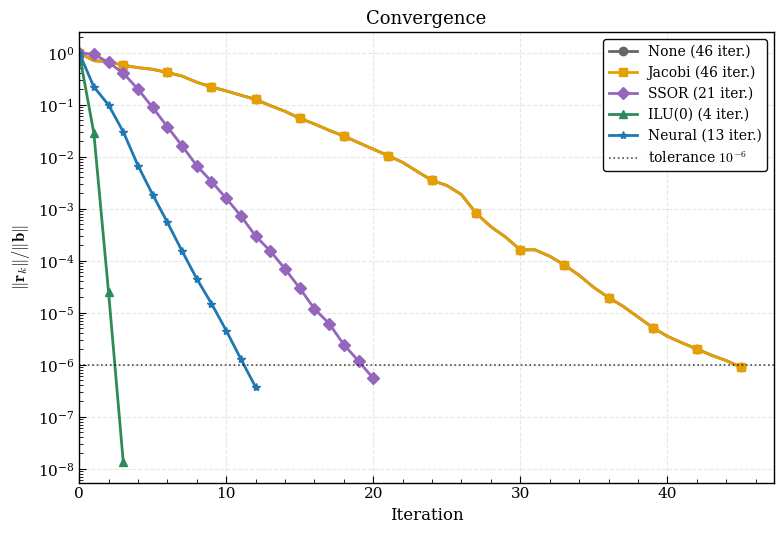

In [12]:
# Problema representativo: gaussiana centrada em (0.5, 0.5)
f = np.exp(-((X_g - 0.5)**2 + (Y_g - 0.5)**2) / 0.05)
b = (h**2) * f.ravel()

# Roda FGMRES com cada precondicionador, guardando residuos
res_curves = {}
for name, factory in precond_factories.items():
    M = factory()
    _, res_history, conv, n_it = fgmres(A, b, M, tol=1e-6, max_iter=300, restart=30)
    res_curves[name] = res_history

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5))

for name, res_hist in res_curves.items():
    ax.semilogy(res_hist,
                label=f"{name} ({len(res_hist)} iter.)",
                color=PRECOND_COLORS[name],
                linewidth=2, marker=PRECOND_MARKERS[name],
                markersize=6, markevery=max(1, len(res_hist)//15))
ax.axhline(1e-6, color="black", linestyle=":", alpha=0.7, linewidth=1.2,
           label=r"tolerance $10^{-6}$")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\mathbf{r}_k\|/\|\mathbf{b}\|$")
ax.set_title("Convergence")
ax.legend(loc='upper right', framealpha=0.95, edgecolor='black', fontsize=10)
ax.set_xlim(left=0)
plt.tight_layout()
save_fig("convergence")
plt.show()

Validacao espectral: erro da rede para diferentes frequencias



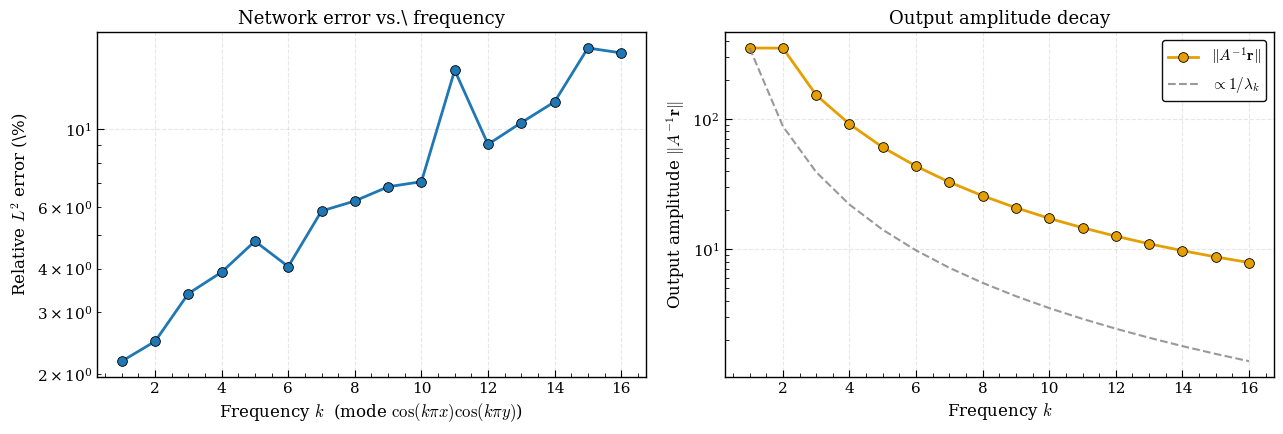

In [13]:
#validacao de modos alto de fourier => pior caso tem L2 grande

# Validacao espectral: erro da rede em funcao da frequencia do modo
print("Validacao espectral: erro da rede para diferentes frequencias\n")

# Gera modos de Fourier puros para varios (kx, ky)
ii, jj = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')
x_grid = (ii + 0.5) / N
y_grid = (jj + 0.5) / N

# Lista de frequencias para testar
k_values = list(range(1, N//2 + 1))   # de 1 até 16

errors_by_freq = []
output_amplitudes = []

for k in k_values:
    # Modo (k, k) -- frequencia "diagonal" simetrica
    r = np.cos(k * np.pi * x_grid) * np.cos(k * np.pi * y_grid)
    r = (r - r.mean()) / (r.std() + 1e-12)   # mesma normalizacao do dataset

    # Solucao exata
    z_exact = solve_A(r.ravel()).reshape(N, N)

    # Predicao da rede (com correcao de escala)
    z_pred = neural_inverse_apply(r.ravel()).reshape(N, N)

    # Erro relativo L2
    err = np.linalg.norm(z_pred - z_exact) / np.linalg.norm(z_exact)
    errors_by_freq.append(err)
    output_amplitudes.append(np.linalg.norm(z_exact))

errors_by_freq = np.array(errors_by_freq)
output_amplitudes = np.array(output_amplitudes)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Painel 1: erro vs frequencia
axes[0].plot(k_values, errors_by_freq * 100,
             marker='o', color='#1F77B4', linewidth=2, markersize=7,
             markeredgecolor='black', markeredgewidth=0.6)
axes[0].set_xlabel(r"Frequency $k$  (mode $\cos(k\pi x)\cos(k\pi y)$)")
axes[0].set_ylabel(r"Relative $L^2$ error (\%)")
axes[0].set_title("Network error vs.\\ frequency")
axes[0].set_yscale('log')
axes[0].set_xticks(range(2, 17, 2))

# Painel 2: amplitude do output
axes[1].plot(k_values, output_amplitudes,
             marker='o', color='#E69F00', linewidth=2, markersize=7,
             markeredgecolor='black', markeredgewidth=0.6,
             label=r"$\|A^{-1}\mathbf{r}\|$")
theoretical = np.array([1/(2 * k**2 * np.pi**2) for k in k_values])
theoretical = theoretical * (output_amplitudes[0] / theoretical[0])
axes[1].plot(k_values, theoretical, '--', color='gray', alpha=0.8, linewidth=1.5,
             label=r"$\propto 1/\lambda_k$")
axes[1].set_xlabel(r"Frequency $k$")
axes[1].set_ylabel(r"Output amplitude $\|A^{-1}\mathbf{r}\|$")
axes[1].set_title("Output amplitude decay")
axes[1].set_yscale('log')
axes[1].set_xticks(range(2, 17, 2))
axes[1].legend(loc='upper right', framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.savefig("fig_spectral.pdf")
plt.show()